# Demo 2. XDS via subprocess calls

**Companion to slide 8 of *Teaching Crystallographic Computing with Computational Notebooks*.**
27th Congress and General Assembly of the IUCr, Calgary, Alberta, 2026 August 17.

Blaine Mooers, PhD. Department of Biochemistry and Physiology, University of Oklahoma Health Campus.
blaine-mooers@ou.edu

## What this demonstration covers

1. Generating `XDS.INP` files programmatically.
2. Running XDS from notebook cells.
3. Parsing `CORRECT.LP` for statistics.
4. Comparing the results with DIALS.

## Why this demonstration exists

DIALS exposes a Python API. XDS does not. XDS reads one keyword file, writes several log
files, and says nothing to the caller except an exit code. Almost every program a student
will ever meet behaves like XDS rather than like DIALS, so learning to drive a file-driven
program from Python is a more transferable skill than learning any single API.

The pattern has three parts, and the three parts recur everywhere.

1. **Write the input.** Build the keyword file from data you already hold in Python
   instead of typing it, because typed geometry is where silent errors enter.
2. **Call the program.** Use `subprocess` and capture the return code, the standard output,
   and the standard error.
3. **Parse the output.** Turn the log file into a data frame, then plot it.

Once students see this pattern they can wrap XDS, SHELXC, Aimless, or a program a
collaborator wrote in 1994 and never documented.

## A word about the license

XDS is free for academic use and ships as a pre-compiled Linux binary, but the license
requires you to register on the XDS web page and receive a download link by email. No
binary is bundled here. Paste your own link into the `XDS_URL` variable below. XDS is
closed source, which is itself worth a minute of discussion beside DIALS.

## Working directory

The directory containing the computational notebook is assumed to be the working directory. It was ./demos.

## How to run this in front of a class

Everything here is fast except the XDS run itself, which takes a few minutes on a
twelve-degree wedge. If you already ran Demo 1 in the same session, the frames are on disk
and this notebook skips the download.

In [4]:
import os

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

import pathlib
import platform
import shutil
import sys

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
print("Python   :", sys.version.split()[0])
print("Platform :", platform.platform())
print("In Colab :", IN_COLAB)

# CUSTOMIZE THE LOCAL PATH
os.chdir("/Users/blaine/3285CCinJNiucr26/demos")

WORK = pathlib.Path("/content/mpro_xds" if IN_COLAB else "./mpro_xds").resolve()
WORK.mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("Working in", WORK)

Python   : 3.14.6
Platform : macOS-26.6.1-arm64-arm-64bit-Mach-O
In Colab : False
Working in /Users/blaine/3285CCinJNiucr26/demos/mpro_xds


## 1. The frames

The same Zenodo wedge Demo 1 used. If the images in Demo 1 are already downloaded, we link to them rather than fetching it twice.

In [5]:
# LOCAL

import concurrent.futures
import os
import pathlib
import sys
import urllib.request

# Belt and braces so this cell runs on its own after a kernel restart.
IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
if "WORK" not in dir():
    WORK = pathlib.Path("/content/mpro_xds" if IN_COLAB else "./mpro_xds").resolve()
    WORK.mkdir(parents=True, exist_ok=True)
    os.chdir(WORK)

RECORD = "3752540"
STEM = "l6p17_09_001"
N_FRAMES = 60

DIALS_FRAMES = pathlib.Path("/content/mpro_dials/frames" if IN_COLAB else "../mpro_dials/frames")
FRAME_DIR = WORK / "frames"

if DIALS_FRAMES.is_dir() and len(list(DIALS_FRAMES.glob("*.cbf"))) >= N_FRAMES:
    if not FRAME_DIR.exists():
        FRAME_DIR.symlink_to(DIALS_FRAMES.resolve(), target_is_directory=True)
    print("Reusing the frames Demo 1 downloaded.")
else:
    FRAME_DIR.mkdir(exist_ok=True)

    def fetch_frame(n: int) -> str:
        dest = FRAME_DIR / f"{STEM}_{n:05d}.cbf"
        if dest.exists() and dest.stat().st_size > 1_000_000:
            return f"cached  {dest.name}"
        url = f"https://zenodo.org/records/{RECORD}/files/{STEM}_{n:05d}.cbf?download=1"
        urllib.request.urlretrieve(url, dest)
        return f"fetched {dest.name}"

    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as pool:
        for msg in pool.map(fetch_frame, range(1, N_FRAMES + 1)):
            print(msg)

frames = sorted(FRAME_DIR.glob(f"{STEM}_*.cbf"))
print(f"\n{len(frames)} frames ready in {FRAME_DIR}")

Reusing the frames Demo 1 downloaded.

60 frames ready in /Users/blaine/3285CCinJNiucr26/demos/mpro_xds/frames


## 2. Install XDS

Replace `XDS_URL` with the address in your academic license email, then run the cell.
The archive is about 20 MB and unpacks in seconds. Dectris took over XDS maintenance in June 2026. You need to register here to get the LICENSE link:  https://www.dectris.com/en/detectors/XDS/#download

In [6]:
# XDS_URL = ""  # Paste your licensed download URL here.

XDS_DIR = WORK / "xds"
XDS_DIR.mkdir(exist_ok=True)

# if XDS_URL:
#     tarball = XDS_DIR / "xds.tar.gz"
#     if not tarball.exists():
#         urllib.request.urlretrieve(XDS_URL, tarball)
#     shutil.unpack_archive(str(tarball), str(XDS_DIR))
#     # The archive expands into a single versioned directory. Put it on PATH.
#     bindir = next(p for p in XDS_DIR.iterdir() if p.is_dir() and (p / "xds_par").exists())
#     os.environ["PATH"] = f"{bindir}:{os.environ['PATH']}"
#     print("XDS binaries on PATH from", bindir)
# else:
#     print("XDS_URL is empty. Set it to your licensed download link and rerun this cell.")

print("xds_par found :", shutil.which("xds_par") is not None)

xds_par found : True


## 3. Build `XDS.INP` from the image headers rather than by hand

This is the pedagogical heart of the notebook. A student who types `ORGX= 1234.5` has no
way to know whether the number is right. A student who reads the beam center out of the
detector model and prints it has a number that came from the data.

We use `dxtbx`, the DIALS image-reading library, as the source of truth. `dxtbx` and XDS
disagree about conventions in a few places, and every one of those disagreements is a
teaching moment about coordinate frames.

In [14]:
from dxtbx.model.experiment_list import ExperimentListFactory

expts = ExperimentListFactory.from_filenames([str(f) for f in frames])
imageset = expts.imagesets()[0]

beam = imageset.get_beam()
panel = imageset.get_detector()[0]
gonio = imageset.get_goniometer()
scan = imageset.get_scan()

nx, ny = panel.get_image_size()
qx, qy = panel.get_pixel_size()
orgx, orgy = panel.get_beam_centre_px(beam.get_s0())

geometry = {
    "NX": nx,
    "NY": ny,
    "QX": qx,
    "QY": qy,
    "ORGX": orgx,
    "ORGY": orgy,
    "DETECTOR_DISTANCE": panel.get_distance(),
    "X-RAY_WAVELENGTH": beam.get_wavelength(),
    "OSCILLATION_RANGE": scan.get_oscillation()[1],
    "STARTING_ANGLE": scan.get_oscillation()[0],
    "ROTATION_AXIS": gonio.get_rotation_axis(),
    # dxtbx's s0 points sample-to-source. XDS expects source-to-sample,
    # so we negate the vector before writing it into XDS.INP.
    "INCIDENT_BEAM_DIRECTION": tuple(-c for c in beam.get_unit_s0()),
}

for key, value in geometry.items():
    print(f"{key:26s} {value}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [00:00<00:00, 886.86it/s]
NX                         2463
NY                         2527
QX                         0.17200000000000001
QY                         0.17200000000000001
ORGX                       1259.0000000000002
ORGY                       1240.0
DETECTOR_DISTANCE          200.0
X-RAY_WAVELENGTH           1.0332
OSCILLATION_RANGE          0.2
STARTING_ANGLE             0.0
ROTATION_AXIS              (1.0, 0.0, 0.0)
INCIDENT_BEAM_DIRECTION    (0.0, 0.0, 1.0)


In [15]:
# Assemble the keyword file. Every value that can come from the header does come from it.
template = FRAME_DIR / f"{STEM}_?????.cbf"

XDS_INP = f"""\
! XDS.INP written by demo2_XDS_via_subprocess.ipynb
! Geometry read from the CBF headers through dxtbx. Do not hand-edit the
! numbers below. Edit the notebook cell that generates them.

JOB= XYCORR INIT COLSPOT IDXREF DEFPIX INTEGRATE CORRECT

! ---- detector ----------------------------------------------------------
DETECTOR= PILATUS
MINIMUM_VALID_PIXEL_VALUE= 0
OVERLOAD= 1048576
SENSOR_THICKNESS= 0.45
NX= {nx}  NY= {ny}  QX= {qx:.6f}  QY= {qy:.6f}
ORGX= {orgx:.2f}  ORGY= {orgy:.2f}
DETECTOR_DISTANCE= {panel.get_distance():.3f}
DIRECTION_OF_DETECTOR_X-AXIS= 1.0 0.0 0.0
DIRECTION_OF_DETECTOR_Y-AXIS= 0.0 1.0 0.0
TRUSTED_REGION= 0.00 1.41

! ---- beam and rotation -------------------------------------------------
X-RAY_WAVELENGTH= {beam.get_wavelength():.6f}
INCIDENT_BEAM_DIRECTION= {" ".join(f"{-c:.6f}" for c in beam.get_unit_s0())}
ROTATION_AXIS= {" ".join(f"{c:.6f}" for c in gonio.get_rotation_axis())}
OSCILLATION_RANGE= {scan.get_oscillation()[1]:.6f}
STARTING_ANGLE= {scan.get_oscillation()[0]:.6f}
STARTING_FRAME= 1
FRACTION_OF_POLARIZATION= 0.99
POLARIZATION_PLANE_NORMAL= 0.0 1.0 0.0

! ---- the frames --------------------------------------------------------
NAME_TEMPLATE_OF_DATA_FRAMES= {template}
DATA_RANGE= 1 {len(frames)}
SPOT_RANGE= 1 {len(frames)}
BACKGROUND_RANGE= 1 {min(20, len(frames))}

! ---- what we do not yet know -------------------------------------------
! Zero means "determine this from the data". Fill these in on a second pass
! once IDXREF has proposed a lattice, then rerun with JOB= DEFPIX INTEGRATE CORRECT.
SPACE_GROUP_NUMBER= 0
UNIT_CELL_CONSTANTS= 0 0 0 0 0 0
FRIEDEL'S_LAW= TRUE
INCLUDE_RESOLUTION_RANGE= 50.0 1.30
MAXIMUM_NUMBER_OF_PROCESSORS= 2
"""

(WORK / "XDS.INP").write_text(XDS_INP)
print(XDS_INP)

! XDS.INP written by demo2_XDS_via_subprocess.ipynb
! Geometry read from the CBF headers through dxtbx. Do not hand-edit the
! numbers below. Edit the notebook cell that generates them.

JOB= XYCORR INIT COLSPOT IDXREF DEFPIX INTEGRATE CORRECT

! ---- detector ----------------------------------------------------------
DETECTOR= PILATUS
MINIMUM_VALID_PIXEL_VALUE= 0
OVERLOAD= 1048576
SENSOR_THICKNESS= 0.45
NX= 2463  NY= 2527  QX= 0.172000  QY= 0.172000
ORGX= 1259.00  ORGY= 1240.00
DETECTOR_DISTANCE= 200.000
DIRECTION_OF_DETECTOR_X-AXIS= 1.0 0.0 0.0
DIRECTION_OF_DETECTOR_Y-AXIS= 0.0 1.0 0.0
TRUSTED_REGION= 0.00 1.41

! ---- beam and rotation -------------------------------------------------
X-RAY_WAVELENGTH= 1.033200
INCIDENT_BEAM_DIRECTION= 0.000000 0.000000 1.000000
ROTATION_AXIS= 1.000000 0.000000 0.000000
OSCILLATION_RANGE= 0.200000
STARTING_ANGLE= 0.000000
STARTING_FRAME= 1
FRACTION_OF_POLARIZATION= 0.99
POLARIZATION_PLANE_NORMAL= 0.0 1.0 0.0

! ---- the frames ----------------------

**DIALS writes this file too.** `dials.export format=xds` produces an `XDS.INP` from an
imported experiment list. Generating the file by hand first and then comparing against the
exported version is a good exercise, because the differences expose exactly which
conventions the two programs treat differently.

## 4. Call XDS through `subprocess`

The important habit is capturing the return code and the output rather than letting a
shell magic swallow them. A helper of ten lines pays for itself immediately.

In [16]:
import subprocess
import time


def run(cmd, cwd=WORK, tail=25, timeout=3600):
    """Run a command, print the last few lines of its output, and return the result.

    Raising on a non-zero return code is deliberate. A silent failure that leaves a
    stale log file on disk is the single most common way a notebook pipeline lies
    to a student.
    """
    started = time.time()
    proc = subprocess.run(
        cmd,
        cwd=str(cwd),
        shell=isinstance(cmd, str),
        capture_output=True,
        text=True,
        timeout=timeout,
    )
    elapsed = time.time() - started
    label = cmd if isinstance(cmd, str) else " ".join(cmd)
    print(f"$ {label}")
    print(f"  return code {proc.returncode}, {elapsed:.1f} s elapsed")
    if proc.stdout.strip():
        print("  --- stdout, last lines ---")
        for line in proc.stdout.rstrip().splitlines()[-tail:]:
            print("  ", line)
    if proc.stderr.strip():
        print("  --- stderr, last lines ---")
        for line in proc.stderr.rstrip().splitlines()[-tail:]:
            print("  ", line)
    if proc.returncode != 0:
        raise RuntimeError(f"{label} failed with code {proc.returncode}")
    return proc


print("Helper defined. Nothing has run yet.")

Helper defined. Nothing has run yet.


In [17]:
# The full XDS run. Comment out this cell and use the staged version below when you
# want to stop after indexing and discuss the lattice with the class.
if shutil.which("xds_par"):
    result = run("xds_par")
else:
    print("xds_par is not on PATH. Set XDS_URL above and rerun the install cell.")

$ xds_par
  return code 0, 4.6 s elapsed
  --- stdout, last lines ---
   
    THE DATA COLLECTION STATISTICS REPORTED BELOW ASSUMES:
    SPACE_GROUP_NUMBER=    5
    UNIT_CELL_CONSTANTS=   113.63    53.15    44.67  90.000 103.138  90.000
   
   
    ******************************************************************************
       CORRECTION PARAMETERS FOR THE STANDARD ERROR OF REFLECTION INTENSITIES
    ******************************************************************************
   
    The variance v0(I) of the intensity I obtained from counting statistics is
    replaced by v(I)=a*(v0(I)+b*I^2). The model parameters a, b are chosen to
    minimize the discrepancies between v(I) and the variance estimated from
    sample statistics of symmetry related reflections. This model implicates
    an asymptotic limit ISa=1/SQRT(a*b) for the highest I/Sigma(I) that the
    experimental setup can produce (Diederichs (2010) Acta Cryst D66, 733-740).
   
        a        b          ISa
    

### Running XDS in stages

XDS reruns from the `JOB=` line, so you can stop after indexing, look at `IDXREF.LP`,
change one keyword, and continue. This is how the program is meant to be used and it
maps cleanly onto a class discussion.

In [18]:
def set_job(stages: str, inp=WORK / "XDS.INP"):
    """Rewrite the JOB= line of XDS.INP in place."""
    lines = inp.read_text().splitlines()
    for i, line in enumerate(lines):
        if line.strip().upper().startswith("JOB="):
            lines[i] = f"JOB= {stages}"
            break
    inp.write_text("\n".join(lines) + "\n")
    print("JOB= set to", stages)


# Example of the staged pattern. Uncomment to use it.
# set_job("XYCORR INIT COLSPOT IDXREF")
# run("xds_par")
# ... inspect IDXREF.LP with the class, choose a lattice ...
# set_job("DEFPIX INTEGRATE CORRECT")
# run("xds_par")

## 5. Parse the logs

XDS writes plain text. Parsing it is a five-line regular expression, and doing that in
front of students demystifies log files permanently.

In [19]:
import re

import pandas as pd


def parse_idxref(path=WORK / "IDXREF.LP"):
    """Pull the indexing summary out of IDXREF.LP."""
    text = pathlib.Path(path).read_text(errors="replace")
    out = {}
    m = re.search(r"UNIT CELL PARAMETERS\s+([\d.\s]+)", text)
    if m:
        out["unit_cell"] = [float(v) for v in m.group(1).split()[:6]]
    m = re.search(r"SPACE GROUP NUMBER\s+(\d+)", text)
    if m:
        out["space_group_number"] = int(m.group(1))
    m = re.search(r"NUMBER OF INDEXED SPOTS\s+(\d+)", text)
    if m:
        out["indexed_spots"] = int(m.group(1))
    m = re.search(r"NUMBER OF SPOTS? THAT (?:COULD|CANNOT) BE INDEXED\s+(\d+)", text)
    if m:
        out["unindexed_spots"] = int(m.group(1))
    m = re.search(r"STANDARD DEVIATION OF SPOT\s+POSITION \(PIXELS\)\s+([\d.]+)", text)
    if m:
        out["rmsd_spot_px"] = float(m.group(1))
    return out


if (WORK / "IDXREF.LP").exists():
    for key, value in parse_idxref().items():
        print(f"{key:22s} {value}")
else:
    print("IDXREF.LP not found. Run XDS first.")

unit_cell              [45.068, 53.235, 63.479, 114.436, 102.674, 90.235]
space_group_number     1
rmsd_spot_px           2.42


In [20]:
def parse_correct_shells(path=WORK / "CORRECT.LP"):
    """Return the resolution shell table from CORRECT.LP as a data frame.

    The table has a fixed column order and a `total` row at the bottom. Matching a
    line of eleven or more numeric fields is enough to find it without depending on
    the exact wording of the header, which has changed between XDS releases.
    """
    text = pathlib.Path(path).read_text(errors="replace")
    block = text.split("STATISTICS OF SAVED DATA SET")[-1]
    rows = []
    number = re.compile(
        r"^\s*(\d+\.\d+|total)\s+(\d+)\s+(\d+)\s+(\d+)\s+([\d.]+)%\s+"
        r"([\d.]+)%\s+([\d.]+)%\s+(\d+)\s+([-\d.]+)\s+([\d.]+)%\s+([-\d.*]+)"
    )
    for line in block.splitlines():
        m = number.match(line)
        if not m:
            continue
        g = m.groups()
        rows.append(
            {
                "resolution": g[0],
                "observed": int(g[1]),
                "unique": int(g[2]),
                "possible": int(g[3]),
                "completeness": float(g[4]),
                "r_merge": float(g[5]),
                "r_expected": float(g[6]),
                "compared": int(g[7]),
                "i_over_sigma": float(g[8]),
                "r_meas": float(g[9]),
                "cc_half": g[10],
            }
        )
    return pd.DataFrame(rows)


if (WORK / "CORRECT.LP").exists():
    shells = parse_correct_shells()
    display(shells)
else:
    shells = pd.DataFrame()
    print("CORRECT.LP not found. Run XDS first.")

,resolution,observed,unique,possible,completeness,r_merge,r_expected,compared,i_over_sigma,r_meas,cc_half
0,3.86,548,323,2532,12.8,3.1,3.3,430,18.72,4.3,99.6*
1,2.74,958,604,4434,13.6,5.4,5.2,708,9.87,7.7,99.5*
2,2.24,1238,770,5671,13.6,17.7,15.9,936,3.97,25.1,94.5*
3,1.94,1427,901,6735,13.4,37.5,36.8,1052,1.86,53.0,82.6*
4,1.74,1608,1000,7585,13.2,96.0,99.1,1216,0.65,135.8,41.8*
5,1.59,1701,1071,8383,12.8,276.6,265.0,1260,0.25,391.2,14.8*
6,1.47,1899,1193,9089,13.1,624.2,628.0,1412,0.09,882.7,6.7
7,1.37,1938,1207,9755,12.4,2637.8,2646.0,1462,0.03,3730.4,6.1
8,total,13398,8378,64528,13.0,19.2,19.0,10020,2.13,27.2,99.2*


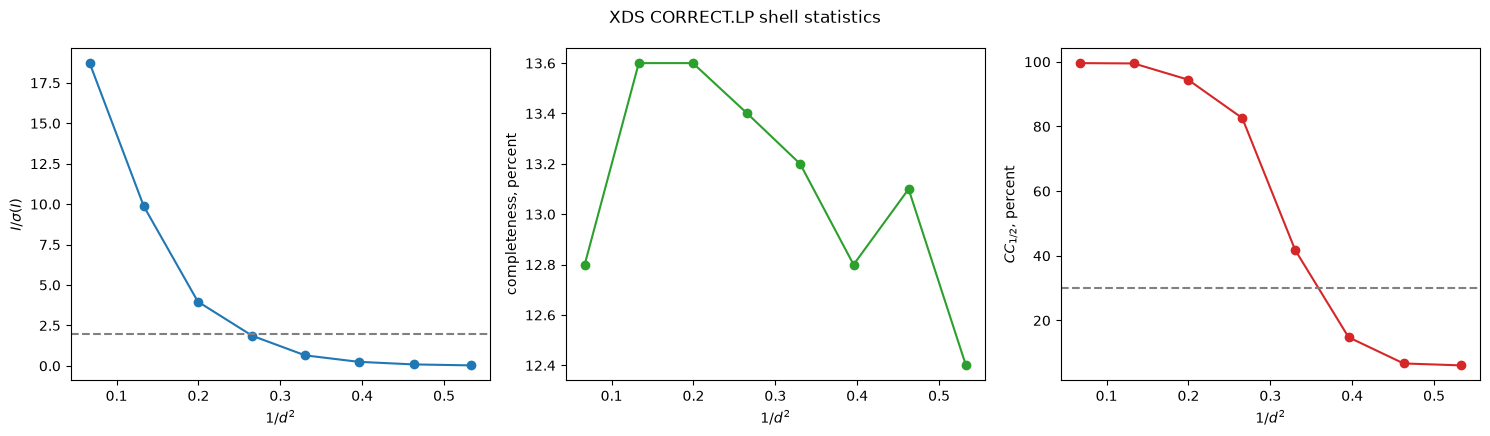

In [21]:
import matplotlib.pyplot as plt
import numpy as np

if not shells.empty:
    binned = shells[shells["resolution"] != "total"].copy()
    binned["d"] = binned["resolution"].astype(float)
    binned["invd2"] = 1.0 / binned["d"] ** 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True)
    axes[0].plot(binned["invd2"], binned["i_over_sigma"], marker="o")
    axes[0].axhline(2.0, ls="--", c="grey")
    axes[0].set_ylabel(r"$I/\sigma(I)$")

    axes[1].plot(binned["invd2"], binned["completeness"], marker="o", color="tab:green")
    axes[1].set_ylabel("completeness, percent")

    cc = pd.to_numeric(binned["cc_half"].str.rstrip("*"), errors="coerce")
    axes[2].plot(binned["invd2"], cc, marker="o", color="tab:red")
    axes[2].axhline(30.0, ls="--", c="grey")
    axes[2].set_ylabel(r"$CC_{1/2}$, percent")

    for ax in axes:
        ax.set_xlabel(r"$1/d^2$")
    fig.suptitle("XDS CORRECT.LP shell statistics")
    plt.tight_layout()
    plt.show()

## 6. Compare XDS against DIALS

Two programs, two algorithms, one crystal. Agreement builds confidence. Disagreement is
more interesting, because it forces the class to ask which assumption differed.

Convert `XDS_ASCII.HKL` to MTZ so both pipelines end in the same file format.

In [22]:
if (WORK / "XDS_ASCII.HKL").exists():
    try:
        run("gemmi xds2mtz XDS_ASCII.HKL xds.mtz")
    except Exception as exc:  # noqa: BLE001
        print("gemmi xds2mtz was unavailable:", exc)
        print("Fall back to the CCP4 route: pointless XDSIN XDS_ASCII.HKL HKLOUT xds.mtz")
else:
    print("XDS_ASCII.HKL not found. Run XDS first.")

$ gemmi xds2mtz XDS_ASCII.HKL xds.mtz
  return code 0, 0.8 s elapsed


In [23]:
import gemmi

comparison = {}

DIALS_MTZ = pathlib.Path("/content/mpro_dials/scaled.mtz" if IN_COLAB else "../mpro_dials/scaled.mtz")
for label, path in [("XDS", WORK / "xds.mtz"), ("DIALS", DIALS_MTZ)]:
    if not path.exists():
        print(f"{label:6s} not available at {path}")
        continue
    mtz = gemmi.read_mtz_file(str(path))
    comparison[label] = {
        "space_group": mtz.spacegroup.hm,
        "a": round(mtz.cell.a, 2),
        "b": round(mtz.cell.b, 2),
        "c": round(mtz.cell.c, 2),
        "alpha": round(mtz.cell.alpha, 1),
        "beta": round(mtz.cell.beta, 1),
        "gamma": round(mtz.cell.gamma, 1),
        "d_min": round(mtz.resolution_high(), 2),
        "reflections": mtz.nreflections,
    }

if comparison:
    display(pd.DataFrame(comparison).T)

,space_group,a,b,c,alpha,beta,gamma,d_min,reflections
XDS,C 1 2 1,113.64,53.15,44.67,90.0,103.1,90.0,1.3,13561
DIALS,I 1 2 1,44.54,53.07,111.86,90.0,100.0,90.0,1.09,11160


**What to say when the numbers differ.** A cell edge that differs by a few hundredths of an
angstrom is normal, because the two programs refine the detector distance against different
residuals. A space group that differs is not a discrepancy at all in most cases, because
XDS `CORRECT` assigns symmetry from the intensities while `dials.index` reports a lattice
from the geometry. Point the class at `dials.symmetry` as the matching step.

A resolution limit that differs by more than about 0.2 angstroms usually means the two runs
applied different cutoff criteria, not that one program saw data the other missed.

## Exercises

1. Change `SPOT_RANGE` to cover only the first fifteen frames and rerun `COLSPOT IDXREF`.
   How few frames can XDS index from?
2. Feed the DIALS unit cell into `UNIT_CELL_CONSTANTS` and `SPACE_GROUP_NUMBER`, then rerun
   `JOB= DEFPIX INTEGRATE CORRECT`. Compare the merging statistics against the unconstrained
   run.
3. Extend the `run` helper so it writes stdout to a file and returns the path, then use it
   to build a table of run times for each XDS stage.
4. Run `dials.export format=xds` on `imported.expt` from Demo 1 and difference the two
   `XDS.INP` files. Explain each difference.

## What to carry forward

The `run` helper reappears in Demo 3 and Demo 4, where it drives CCP4 and Phenix. The
pattern is the deliverable, not the XDS run.

## Sources

* XDS. https://xds.mr.mpg.de.  Kabsch (2010) Acta Cryst. Sect. D 66, 125–132.
* DIALS documentation. https://dials.github.io
* Zenodo record 3752540. https://doi.org/10.5281/zenodo.3752540